In [93]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import scipy
import matplotlib as mpl
from scipy.special import gamma

STARTING_RANGE_PARAMETER = 0.01 # In [fm^-2]
ENDING_RANGE_PARAMETER = 250
REDUCED_MASS = 935 * (4 / 5) # In [Mev / c^2], need to update value and units (10/11 A in MeV)
SUM_LIMIT = 50 # Determines the number of gaussians we expand our wave function to

V_LS = 11.71 # In MeV
DIFFUSIVITY = 0.6 # Diffusivity, may want to check the vaidity of this paticular number
r_0 = 1.2 # In fm, may want to chose a better value for small nuclei
A_C = 4 # The number of nucleons in the core

CENTRAL_POTENTIAL_PARAMETERS = [1 / ((2.30 * 1)**2)]

CENTRAL_MIXING_COEFFICIENTS = [1]

SPIN_ORBIT_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

SPIN_ORBIT_MIXING_COEFFICIENTS = [1]

In [94]:
def single_particle_overlap(range_parameter_i, range_parameter_j):
    return ((2 * range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**(1.5)

def single_particle_potential_element(range_parameter_i, range_parameter_j, central_potential_mixing_coefficient,
                             central_potential_param):
    V_0 = -47.32 * 2
    term_1 = 2 / (range_parameter_i * range_parameter_j)
    term_2 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + central_potential_param)
    return V_0 * (term_1 * term_2)**(1.5)

def single_particle_kinetic_element(range_parameter_i, range_parameter_j, μ=REDUCED_MASS):
    term_1 = range_parameter_i**2 + range_parameter_j**2
    return (197**2 / (2 * μ)) * 6 * single_particle_overlap(range_parameter_i, range_parameter_j) / term_1

def super_symmetric_potential_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                      central_potential_param, k_value, μ=REDUCED_MASS):
    """
    Supersymmetric potential that removes the bound 1s groundstate
    associated with the neutrons in the He-4 core.
    """
    core_neutron_potential =  potential_matrix_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                                       central_potential_param)
    alpha_k = 1 / next_range_parameter(k_value)**0.5
    super_symmetry_term = 2 * (197**2 / μ) * alpha_k**(-2) *  overlap_matrix_element(range_param_i, range_param_j)
    return core_neutron_potential + super_symmetry_term

In [95]:
def matrix_generation(central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)

    return h_matrix, n_matrix

def next_range_parameter(i, starting_range_parameter=STARTING_RANGE_PARAMETER, ending_range_parameter=ENDING_RANGE_PARAMETER,
                         sum_limit=SUM_LIMIT):
    """
    Finds the next range parameter given the previous and initial range parameters.
    Currently using a simple geometric series to determine range parameters.
    Chose geometric basis parameters $\alpha_i = \alpha_1a^{i-1}$ with initial parameters $\alpha_1 = 0.01, a=2$

    Parameters
    ----------
    i : int detailing the iteration number

    Returns
    -------
    new_range_parameter: float

    """
    geometric_progression_number = (ending_range_parameter / starting_range_parameter)**(1 / (sum_limit - 1))
    new_range_parameter = starting_range_parameter * geometric_progression_number**(i)
    #new_range_parameter = 1 / new_range_parameter**2

    return new_range_parameter

#theta = 5 * np.pi / 36 
#s_h_matrix, s_n_matrix = matrix_generation(0.5, 0, theta)
#p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, theta)
#p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, theta)
#d_five_half_h_matrix, d_five_half_n_matrix = matrix_generation(2.5, 2, theta)

In [96]:
s_h_matrix, s_n_matrix = matrix_generation()
s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(s_h_matrix, s_n_matrix)
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(s_n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is", s_overlap_matrix_condition_number)

s0_eigenvector = np.asmatrix(s_eigenvectors[:, 0])
s1_eigenvector = np.asmatrix(s_eigenvectors[:, 1])
s2_eigenvector = np.asmatrix(s_eigenvectors[:, 2])
s3_eigenvector = np.asmatrix(s_eigenvectors[:, 3])
print("The S state eigenvalues are", s_eigenvalues)
print("The S0 eigenvector is", s0_eigenvector)
#print(s_eigenvalues[0])

The s 1/2 overlap matrix condition number is 846715687.1848654
The S state eigenvalues are [-3.97191215e+01 -2.92477531e-01  6.45043993e-04  2.68477672e-03
  6.45840867e-03  1.26180229e-02  2.22689733e-02  3.71964075e-02
  6.02243526e-02  9.57824977e-02  1.50794370e-01  2.36058878e-01
  3.68401057e-01  5.74051400e-01  8.94041786e-01  1.39292630e+00
  2.17302244e+00  3.39769826e+00  5.32938520e+00  8.39006870e+00
  1.32536676e+01  2.09786111e+01  3.32006415e+01  5.24622577e+01
  8.26796743e+01  1.29764209e+02  2.02844347e+02  3.16250921e+02
  4.91966017e+02  7.62905648e+02  1.17812816e+03  1.81115881e+03
  2.77278883e+03  4.23042569e+03  6.43729227e+03  9.77656442e+03
  1.48282216e+04  2.24705014e+04  3.40342574e+04  5.15386583e+04
  7.80530847e+04  1.18257545e+05  1.79322015e+05  2.72314575e+05
  4.14528302e+05  6.33517619e+05  9.74648449e+05  1.51701202e+06
  2.41434883e+06  4.04931985e+06]
The S0 eigenvector is [[ 2.63469149e-09 -1.70906658e-08  5.94603040e-08 -1.50792174e-07
   3.17

Ground state wavefunction has overlap 1.0000000000000009 with itself


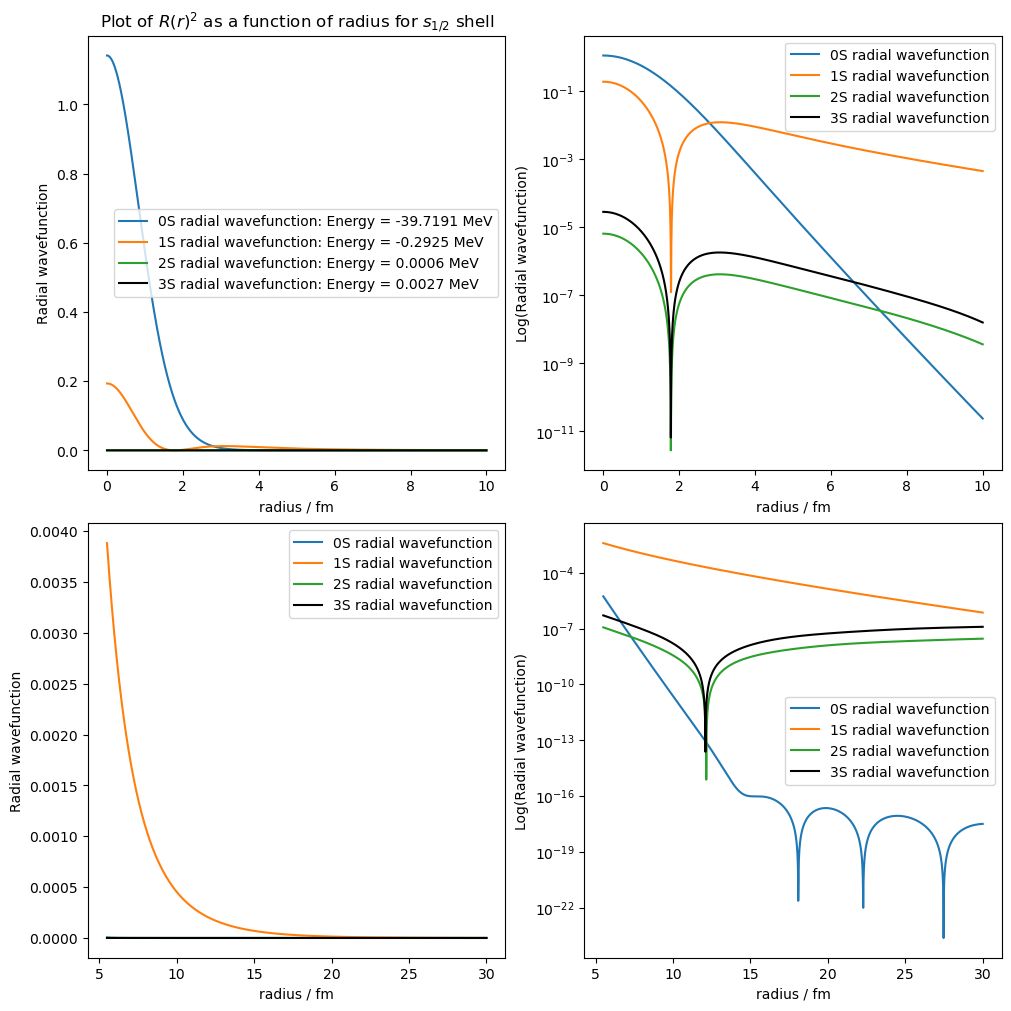

In [97]:
def wavefunction_overlap(orb_ang_momentum_i, orb_ang_momentum_j, i_mixing_coefficients, j_mixing_coefficients, overlap_matrix=None, size=SUM_LIMIT):
    try:
        _ = overlap_matrix.shape
        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
    except AttributeError:
        overlap_matrix = np.zeros(shape=(size, size))

        for i in range(size):
            i_range_parameter = next_range_parameter(i)
            for j in range(size):
                j_range_parameter = next_range_parameter(j)
                overlap_matrix[i, j] = different_l_overlap_matrix_element(orb_ang_momentum_i, orb_ang_momentum_j, i_range_parameter, j_range_parameter)

        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
print(f'Ground state wavefunction has overlap {wavefunction_overlap(0, 0, s0_eigenvector, s0_eigenvector, overlap_matrix=s_n_matrix)} with itself')

def radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number, sum_limit=SUM_LIMIT):
    """
    Defines a numerical method of finding the reduced radial wavefunction as a sum of our gaussians.
    """
    def gaussian_wavefunction(radius, range_parameter, orb_ang_momentum):
        normalisation = (2**(-2.5 - orb_ang_momentum) * (range_parameter)**(3 + 2 * orb_ang_momentum) * gamma(1.5 + orb_ang_momentum))**(-0.5)
        return normalisation * radius**(orb_ang_momentum) * np.exp(- (radius / range_parameter)**2)
    wavefunction_vals = np.zeros(shape=(len(x_values),))

    for i in range(len(x_values)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            wavefunction_vals[i] += (wavefunction_eigenvector[0, j] * gaussian_wavefunction(x_values[i], 
                range_parameter, orbital_quantum_number))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

x_values = np.linspace(0, 10, 3000)
x_values_2 = np.linspace(5.5, 30, 3000)

fig = plt.figure(figsize=(10, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[1,0])
ax_4 = fig.add_subplot(spec[1,1])
ax_1.set_title(r'Plot of $R(r)^{2}$ as a function of radius for $s_{1/2}$ shell')
ax_1.set_xlabel('radius / fm')
ax_1.set_ylabel('Radial wavefunction')
ax_1.plot(x_values, radial_wavefunction(x_values, s0_eigenvector, 0),
          label=f"0S radial wavefunction: Energy = {s_eigenvalues[0]:.4f} MeV")
ax_1.plot(x_values, radial_wavefunction(x_values, s1_eigenvector, 0),
          label=f"1S radial wavefunction: Energy = {s_eigenvalues[1]:.4f} MeV")
ax_1.plot(x_values, radial_wavefunction(x_values, s2_eigenvector, 0),
          label=f"2S radial wavefunction: Energy = {s_eigenvalues[2]:.4f} MeV")
ax_1.plot(x_values, radial_wavefunction(x_values, s3_eigenvector, 0),
          label=f"3S radial wavefunction: Energy = {s_eigenvalues[3]:.4f} MeV", c='k')
ax_1.legend()

ax_2.set_xlabel('radius / fm')
ax_2.set_ylabel('Log(Radial wavefunction)')
ax_2.semilogy(x_values, radial_wavefunction(x_values, s0_eigenvector, 0), label="0S radial wavefunction")
ax_2.semilogy(x_values, radial_wavefunction(x_values, s1_eigenvector, 0), label="1S radial wavefunction")
ax_2.semilogy(x_values, radial_wavefunction(x_values, s2_eigenvector, 0), label="2S radial wavefunction")
ax_2.semilogy(x_values, radial_wavefunction(x_values, s3_eigenvector, 0), label="3S radial wavefunction", c='k')
ax_2.legend()

ax_3.set_xlabel('radius / fm')
ax_3.set_ylabel('Radial wavefunction')
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s1_eigenvector, 0), label="1S radial wavefunction")
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s2_eigenvector, 0), label="2S radial wavefunction")
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s3_eigenvector, 0), label="3S radial wavefunction", c='k')
ax_3.legend()

ax_4.set_xlabel('radius / fm')
ax_4.set_ylabel('Log(Radial wavefunction)')
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s1_eigenvector, 0), label="1S radial wavefunction")
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s2_eigenvector, 0), label="2S radial wavefunction")
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s3_eigenvector, 0), label="3S radial wavefunction", c='k')
ax_4.legend()



C:\Users\faola\AppData\Local\Temp\ipykernel_8580\597162922.py:31: RuntimeWarning: divide by zero encountered in scalar divide
  -differentiated_wavefunction_vals[i] + (superpotential_vals_1[i] / superpotential_vals_2[i]
C:\Users\faola\AppData\Local\Temp\ipykernel_8580\597162922.py:31: RuntimeWarning: invalid value encountered in scalar multiply
  -differentiated_wavefunction_vals[i] + (superpotential_vals_1[i] / superpotential_vals_2[i]


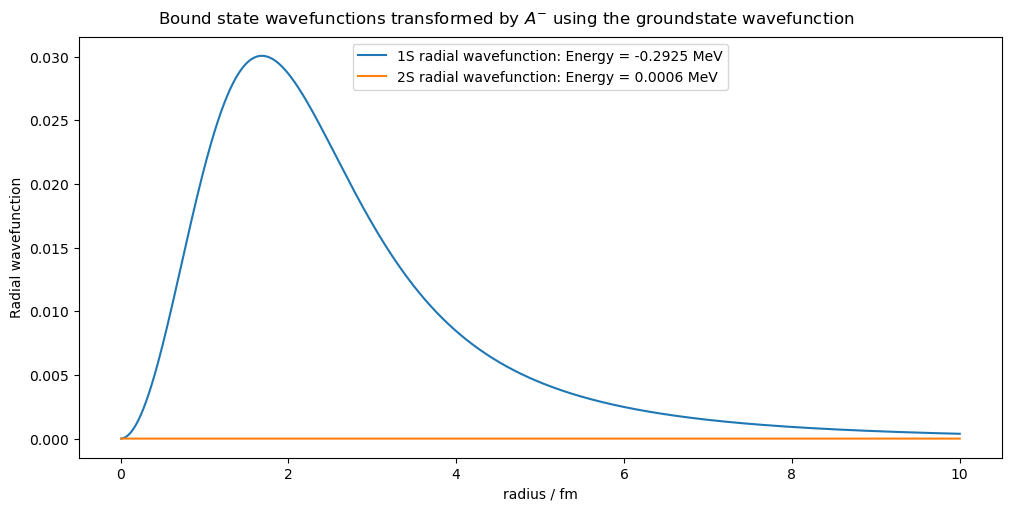

In [98]:
def susy_transformed_wavefunc(radius, inital_wavefunc_eigenvector, inital_wavefunc_energy, gs_eigenvector,
                              gs_energy, sum_limit=SUM_LIMIT):
    differentiated_wavefunction_vals = np.zeros(shape=(len(radius),))
    superpotential_vals_1 = np.zeros(shape=(len(radius),))
    superpotential_vals_2 = np.zeros(shape=(len(radius),))
    inital_wavefunction_vals = np.zeros(shape=(len(radius),))
    wavefunction_vals = np.zeros(shape=(len(radius),))

    def reduced_gaussian_wavefunction(radius, range_parameter):
        normalisation = (2**(-2.5) * (range_parameter)**(3) * gamma(1.5))**(-0.5)
        return normalisation * radius * np.exp(-(radius / range_parameter)**2)

    def reduced_diffentiated_gaussian_wavefunction(radius, range_parameter):
        normalisation = (2**(-2.5) * (range_parameter)**(3) * gamma(1.5))**(-0.5)
        return normalisation * (1 - 2 * (radius**2 / range_parameter**2)) * np.exp(-(radius / range_parameter)**2)

    susy_normalisation = (inital_wavefunc_energy - gs_energy)**(-0.5)

    for i in range(len(radius)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            inital_wavefunction_vals[i] += (inital_wavefunc_eigenvector[0, j] * reduced_gaussian_wavefunction(radius[i], 
                range_parameter))
            differentiated_wavefunction_vals[i] += (inital_wavefunc_eigenvector[0, j] * reduced_diffentiated_gaussian_wavefunction(radius[i], 
                range_parameter))
            superpotential_vals_1[i] += (gs_eigenvector[0, j] * reduced_diffentiated_gaussian_wavefunction(radius[i], 
                range_parameter))
            superpotential_vals_2[i] += (gs_eigenvector[0, j] * reduced_gaussian_wavefunction(radius[i], 
                range_parameter))
        wavefunction_vals[i] = (197 / np.sqrt(2 * REDUCED_MASS)) * susy_normalisation * (
            -differentiated_wavefunction_vals[i] + (superpotential_vals_1[i] / superpotential_vals_2[i]
                                                   ) * inital_wavefunction_vals[i]) / radius[i]
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals


x_values = np.linspace(0, 10, 1500)
susy_transformed_wavefunc

fig = plt.figure(figsize=(10, 5), layout='constrained')
#spec = fig.add_gridspec(ncols=2, nrows=1)
fig.suptitle(r"Bound state wavefunctions transformed by $A^{-}$ using the groundstate wavefunction")
ax_1 = fig.add_subplot()
#ax_2 = fig.add_subplot(spec[0, 1])
ax_1.set_xlabel('radius / fm')
ax_1.set_ylabel('Radial wavefunction')
ax_1.plot(x_values, susy_transformed_wavefunc(x_values, s1_eigenvector, s_eigenvalues[1],
                                              s0_eigenvector, s_eigenvalues[0]),
          label=f"1S radial wavefunction: Energy = {s_eigenvalues[1]:.4f} MeV")
ax_1.plot(x_values, susy_transformed_wavefunc(x_values, s2_eigenvector, s_eigenvalues[2],
                                              s0_eigenvector, s_eigenvalues[0]),
          label=f"2S radial wavefunction: Energy = {s_eigenvalues[2]:.4f} MeV")
#ax_2.plot(x_values, susy_transformed_wavefunc(x_values, s3_eigenvector, s_eigenvalues[3],
#                                              s0_eigenvector, s_eigenvalues[0]),
#          label=f"3S radial wavefunction: Energy = {s_eigenvalues[3]:.4f} MeV")
ax_1.legend(loc='upper center')
#ax_2.legend()



We want to quickly do a superpotential plot for a few other wavefuncs to see how they behave at nodes

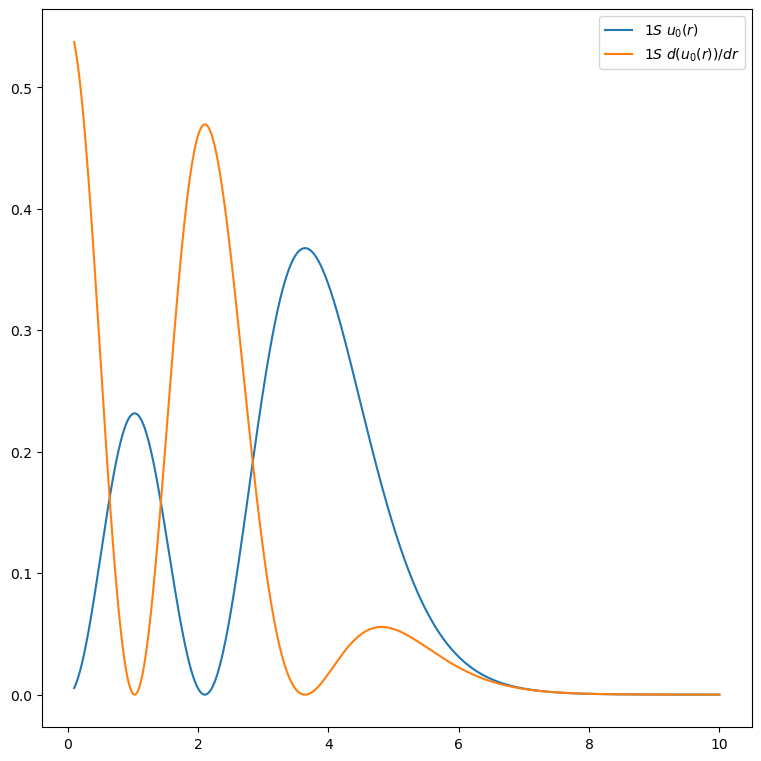

In [46]:
def reduced_gaussian_wavefunction(radius, range_parameter):
    normalisation = (2**(-2.5) * (range_parameter)**(3) * gamma(1.5))**(-0.5)
    return normalisation * radius * np.exp(-(radius / range_parameter)**2)

def reduced_diffentiated_gaussian_wavefunction(radius, range_parameter):
    normalisation = (2**(-2.5) * (range_parameter)**(3) * gamma(1.5))**(-0.5)
    return normalisation * (1 - 2 * (radius**2 / range_parameter**2)) * np.exp(-(radius / range_parameter)**2)

def superpotential_plot(radius, wavefunc_eigenvector, sum_limit=SUM_LIMIT):
    superpotential_vals_1 = np.zeros(shape=(len(radius),))
    superpotential_vals_2 = np.zeros(shape=(len(radius),))
    wavefunction_vals = np.zeros(shape=(len(radius),))

    for i in range(len(radius)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            superpotential_vals_1[i] += (wavefunc_eigenvector[0, j] * reduced_diffentiated_gaussian_wavefunction(radius[i], 
                range_parameter))
            superpotential_vals_2[i] += (wavefunc_eigenvector[0, j] * reduced_gaussian_wavefunction(radius[i], 
                range_parameter))
        wavefunction_vals[i] = superpotential_vals_1[i] / superpotential_vals_2[i]
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

def reduced_r_func_plot(radius, wavefunc_eigenvector, sum_limit=SUM_LIMIT):
    wavefunction_vals = np.zeros(shape=(len(radius),))
    for i in range(len(radius)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            wavefunction_vals[i] += (wavefunc_eigenvector[0, j] * reduced_gaussian_wavefunction(radius[i], 
                range_parameter))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

def deriv_reduced_r_func_plot(radius, wavefunc_eigenvector, sum_limit=SUM_LIMIT):
    wavefunction_vals = np.zeros(shape=(len(radius),))
    for i in range(len(radius)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            wavefunction_vals[i] += (wavefunc_eigenvector[0, j] * reduced_diffentiated_gaussian_wavefunction(radius[i], 
                range_parameter))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals


x_values = np.linspace(0.1, 10, 1000)

fig = plt.figure(figsize=(7.5, 7.5), layout='constrained')
ax_1 = fig.add_subplot()
#ax_1.plot(x_values, superpotential_plot(x_values, s0_eigenvector), label="0S Superpotential")
#ax_1.plot(x_values, superpotential_plot(x_values, s1_eigenvector), label="1S Superpotential")
#ax_1.plot(x_values, superpotential_plot(x_values, s2_eigenvector), label="2S Superpotential")
#ax_1.plot(x_values, reduced_r_func_plot(x_values, s0_eigenvector), label=r'$0S$ $u_{0}(r)$')
#ax_1.plot(x_values, deriv_reduced_r_func_plot(x_values, s0_eigenvector), label=r'$0S$ $d(u_{0}(r))/dr$')
ax_1.plot(x_values, reduced_r_func_plot(x_values, s1_eigenvector), label=r'$1S$ $u_{0}(r)$')
ax_1.plot(x_values, deriv_reduced_r_func_plot(x_values, s1_eigenvector), label=r'$1S$ $d(u_{0}(r))/dr$')
#ax_1.plot(x_values, reduced_r_func_plot(x_values, s2_eigenvector), label=r'$2S$ $u_{0}(r)$')
#ax_1.plot(x_values, deriv_reduced_r_func_plot(x_values, s2_eigenvector), label=r'$2S$ $d(u_{0}(r))/dr$')
ax_1.legend()
